# Diffusion model to generate new images


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 19.7 MB/s eta 0:00:00


In [ ]:
!pip install diffusers

In [ ]:
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 113.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvj

Installing packages

In [ ]:
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt
import optuna

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Defining the Diffusion Trainer class

In [ ]:


class DiffusionTrainer:
    """
    A class encapsulating the training and sampling procedures of a Denoising Diffusion Probabilistic Model (DDPM).

    This class implements:
    - Forward diffusion process using a noise scheduler (q(x_t | x_0))
    - Training of a UNet neural network to predict added noise at any timestep
    - Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None, lr=1e-4):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            scheduler_kwargs: Dictionary of keyword arguments to customize the DDPMScheduler.
                Accepts keys such as:
                    - beta_schedule (str): e.g., "linear", "scaled_linear", "squaredcos_cap_v2"
                    - beta_start (float): Initial beta value for linear schedules
                    - beta_end (float): Final beta value for linear schedules
                    - num_train_timesteps (int): Total number of diffusion steps
            lr: Learning rate for the optimizer
        """
        self.device = device
        self.model = UNet2DModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {
                "beta_schedule": "squaredcos_cap_v2",
                "num_train_timesteps": 1000
            }

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for batch, _ in dataloader:
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

            torch.save(
                self.model.state_dict(),
                f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_{self.noise_scheduler.config.beta_schedule}_number_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generate images by reversing the diffusion process starting from noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 1, 28, 28, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img


def objective(trial):
    """
    Optuna objective function for hyperparameter tuning of the DDPM.
    Tunes the beta_start, beta_end, and learning rate.
    """
    scheduler_params = {
        "beta_schedule": trial.suggest_categorical("beta_schedule", ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]),
        "beta_start": trial.suggest_float("beta_start", 1e-5, 1e-3, log=True),
        "beta_end": trial.suggest_float("beta_end", 0.01, 0.2),
        "num_train_timesteps": 1000
    }
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params, lr=lr)
    trainer.model.train()

    losses = []
    for batch, _ in train_dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, trainer.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_batch = trainer.noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = trainer.model(noisy_batch, timesteps).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        trainer.optimizer.zero_grad()
        loss.backward()
        trainer.optimizer.step()

        losses.append(loss.item())
        if len(losses) > 10:
            break

    return sum(losses) / len(losses)

def plot_noise(scheduler_kwargs=None):
    if scheduler_kwargs is None:
        scheduler_kwargs = {}
    noise_scheduler = DDPMScheduler(**scheduler_kwargs)
    schedule_name = scheduler_kwargs.get("beta_schedule", "Unknown Schedule")

    plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"$\sqrt{\bar{\alpha}_t}$")

    plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{1 - \bar{\alpha}_t}$")

    plt.xlabel('Time step')
    plt.ylabel('Value')
    if schedule_name:
        plt.title(f'Noise Scheduler Parameters with {schedule_name}')
    else:
        plt.title('Noise Scheduler Parameters')
    plt.legend(fontsize="x-large")
    plt.show()

def plot_generated_samples(samples, num_samples=16, title="Generated Samples"):
    """
    Plot a grid of generated samples.

    Args:
        samples: A batch of generated images as a torch tensor.
        num_samples: Number of samples to plot.
        title: Title for the plot.
    """
    grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

    plt.figure(figsize=(6, 6))
    plt.title("Generated Samples")
    plt.imshow(grid[0], cmap='Greys')
    plt.axis('off')
    plt.show()
import torchvision.transforms as T

def visualize_forward_diffusion(trainer, dataset, schedule_name, num_steps=8):
    """
    Visualize the forward diffusion process for an example image from the dataset.

    Args:
        trainer: A DiffusionTrainer instance (already configured with a specific noise schedule).
        dataset: The dataset to draw an example image from.
        schedule_name: The name of the noise schedule (for the plot title).
        num_steps: Number of timesteps to visualize (evenly spaced).
    """
    trainer.model.eval()
    noise_scheduler = trainer.noise_scheduler


    img, _ = dataset[0]
    img = img.unsqueeze(0).to(trainer.device)


    timesteps = torch.linspace(0, noise_scheduler.config.num_train_timesteps - 1, num_steps).long().to(trainer.device)


    plt.figure(figsize=(2.5 * num_steps, 2.5))

    for i, t in enumerate(timesteps):
        noise = torch.randn_like(img)
        noised_img = noise_scheduler.add_noise(img, noise, t)

        noised_img_vis = (noised_img[0].detach().cpu().clamp(-1, 1) + 1) / 2
        plt.subplot(1, num_steps, i + 1)
        if noised_img_vis.shape[0] == 1:
            plt.imshow(noised_img_vis[0], cmap="gray")
        else:
            plt.imshow(noised_img_vis.permute(1, 2, 0))
        plt.title(f"t={t.item()}")
        plt.axis("off")

    plt.suptitle(f"Forward Process — {schedule_name} Schedule", fontsize=16)
    plt.show()




Setting the environment and loading the data set

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)



Using device: cuda


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.28MB/s]


### Exploring different noise schedules

In [ ]:
beta_schedules = ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]

#### Focusing on the forward pass

Training with linear schedule


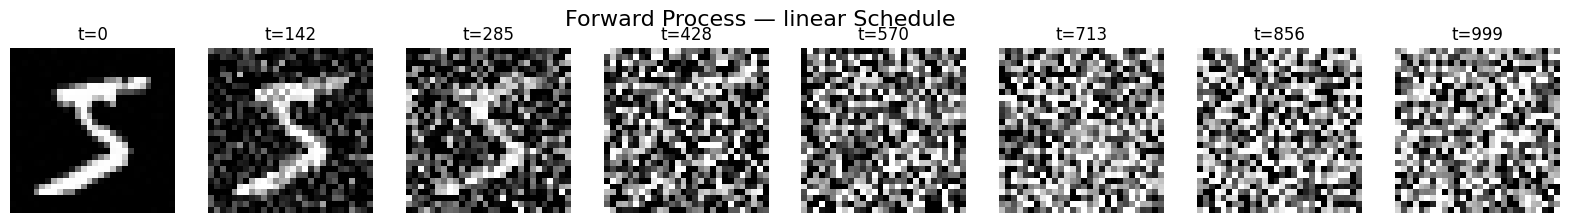

Training with scaled_linear schedule


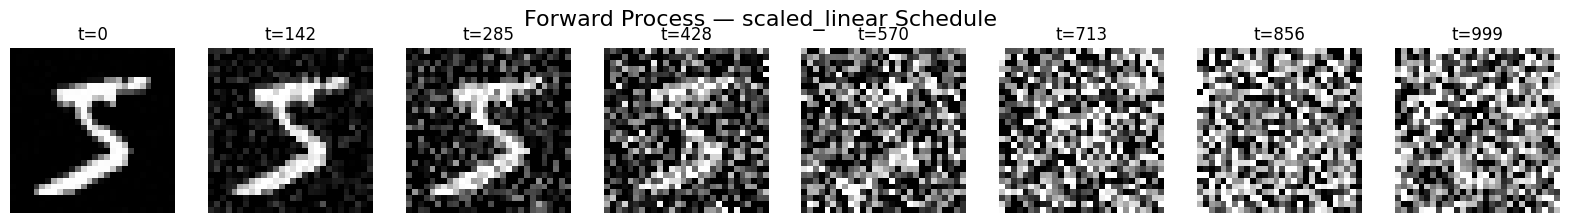

Training with squaredcos_cap_v2 schedule


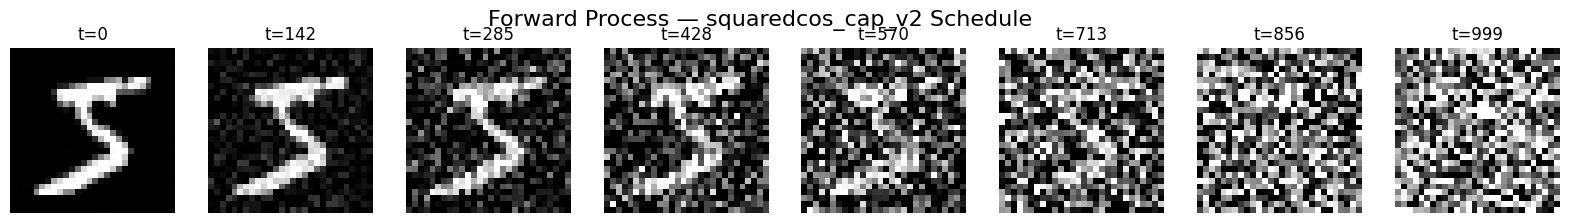

Training with sigmoid schedule


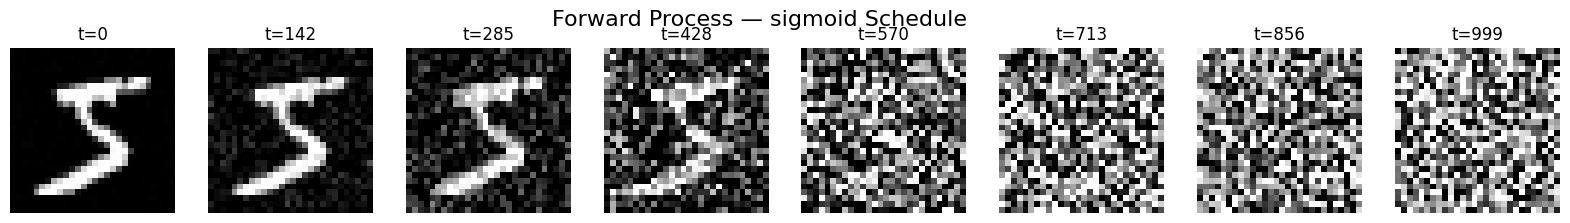

In [ ]:
for schedule in beta_schedules:
  print(f"Training with {schedule} schedule")
  scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }
  trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)
  visualize_forward_diffusion(trainer, dataset, schedule_name=trainer.noise_scheduler.config.beta_schedule, num_steps=8)

#### Generating images using different schedules

Training with linear schedule


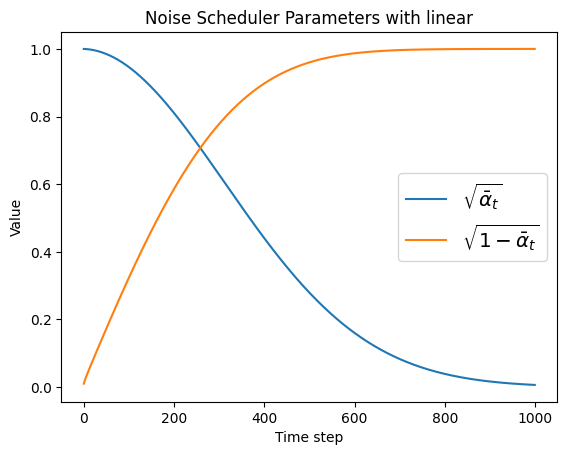

Epoch 1/10, Avg Loss: 0.09501
Epoch 2/10, Avg Loss: 0.04016
Epoch 3/10, Avg Loss: 0.03442
Epoch 4/10, Avg Loss: 0.03187
Epoch 5/10, Avg Loss: 0.03008
Epoch 6/10, Avg Loss: 0.02902
Epoch 7/10, Avg Loss: 0.02798
Epoch 8/10, Avg Loss: 0.02743
Epoch 9/10, Avg Loss: 0.02655
Epoch 10/10, Avg Loss: 0.02575


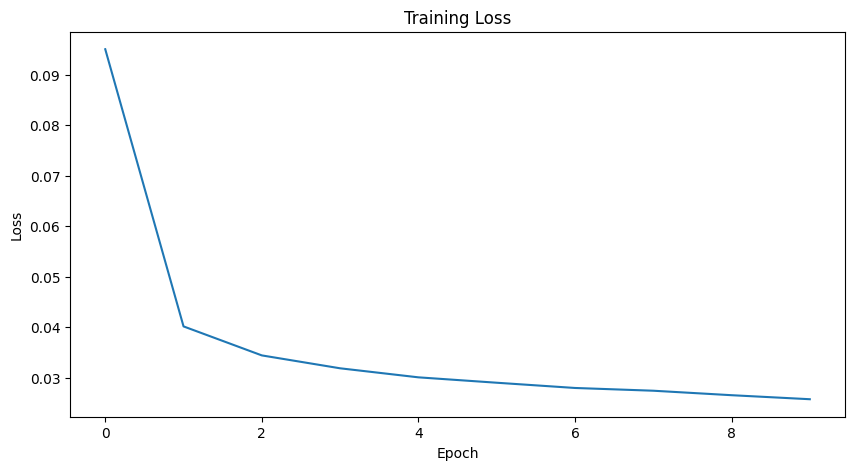

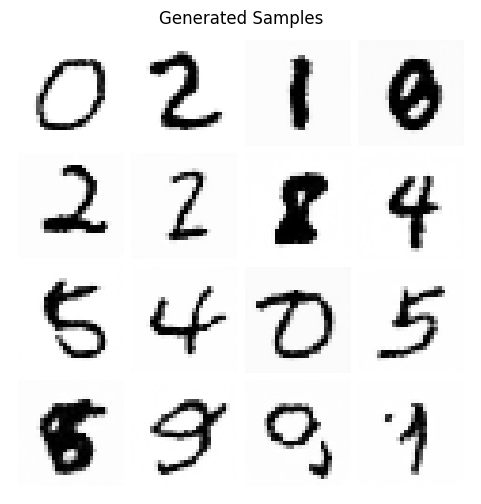

Training with scaled_linear schedule


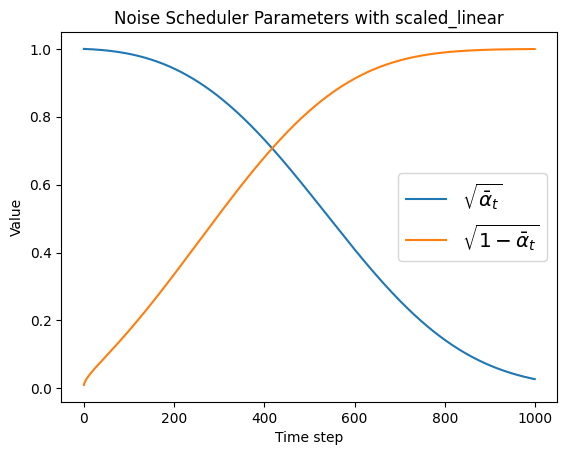

Epoch 1/10, Avg Loss: 0.12957
Epoch 2/10, Avg Loss: 0.05856
Epoch 3/10, Avg Loss: 0.04954
Epoch 4/10, Avg Loss: 0.04561
Epoch 5/10, Avg Loss: 0.04393
Epoch 6/10, Avg Loss: 0.04221
Epoch 7/10, Avg Loss: 0.04102
Epoch 8/10, Avg Loss: 0.04017
Epoch 9/10, Avg Loss: 0.03949
Epoch 10/10, Avg Loss: 0.03894


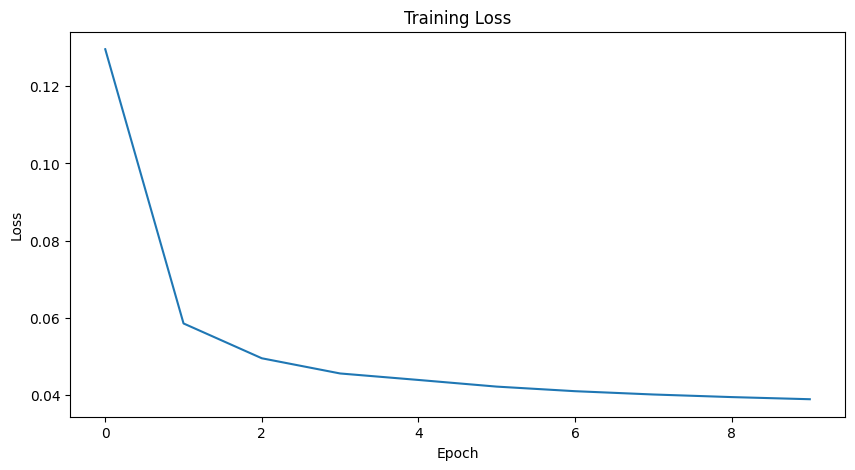

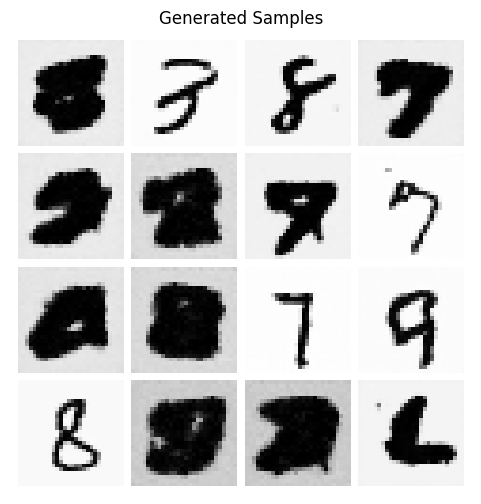

Training with squaredcos_cap_v2 schedule


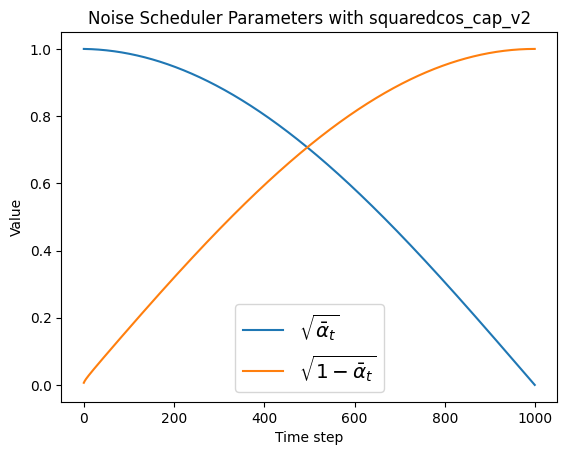

Epoch 1/10, Avg Loss: 0.13730
Epoch 2/10, Avg Loss: 0.06390
Epoch 3/10, Avg Loss: 0.05527
Epoch 4/10, Avg Loss: 0.05172
Epoch 5/10, Avg Loss: 0.04893
Epoch 6/10, Avg Loss: 0.04734
Epoch 7/10, Avg Loss: 0.04597
Epoch 8/10, Avg Loss: 0.04523
Epoch 9/10, Avg Loss: 0.04474
Epoch 10/10, Avg Loss: 0.04400


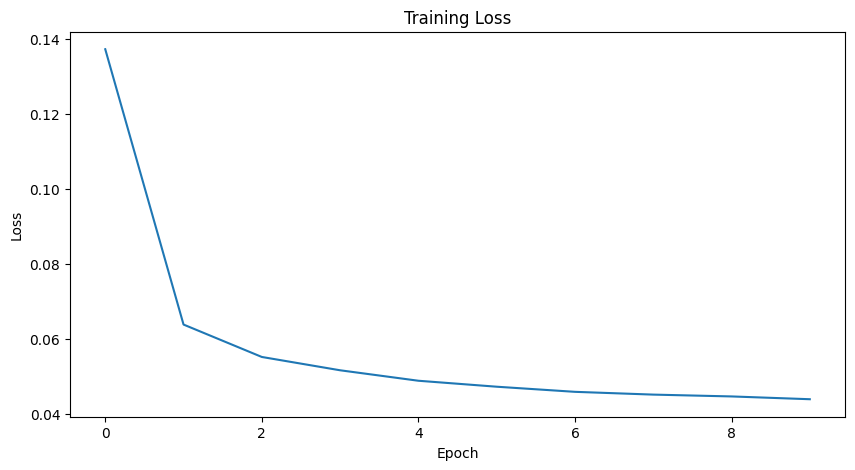

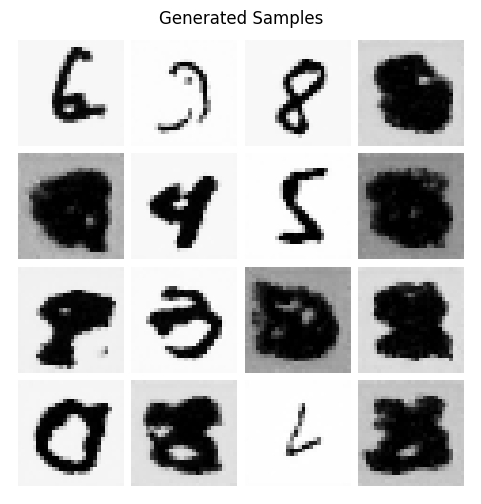

Training with sigmoid schedule


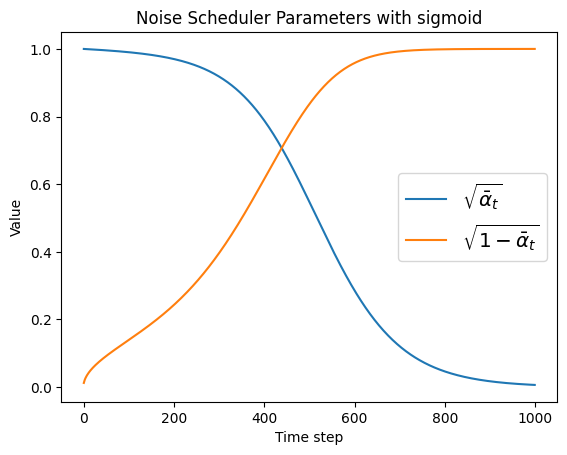

Epoch 1/10, Avg Loss: 0.12789
Epoch 2/10, Avg Loss: 0.05788
Epoch 3/10, Avg Loss: 0.05034
Epoch 4/10, Avg Loss: 0.04699
Epoch 5/10, Avg Loss: 0.04421
Epoch 6/10, Avg Loss: 0.04278
Epoch 7/10, Avg Loss: 0.04216
Epoch 8/10, Avg Loss: 0.04144
Epoch 9/10, Avg Loss: 0.04021
Epoch 10/10, Avg Loss: 0.04006


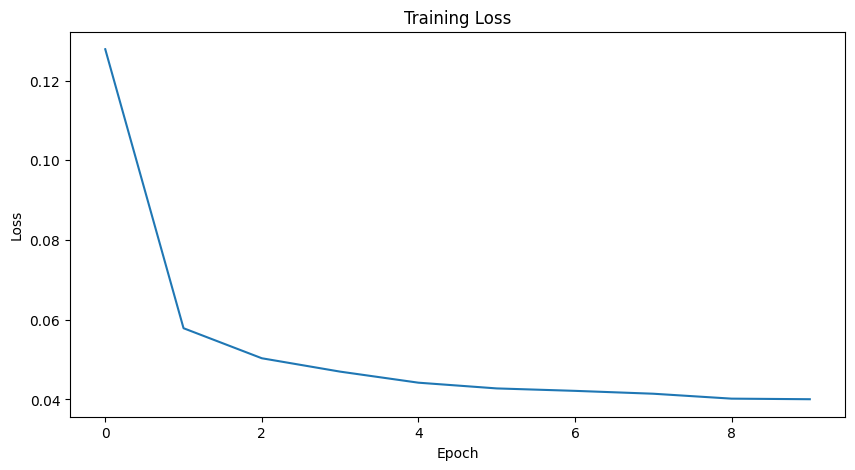

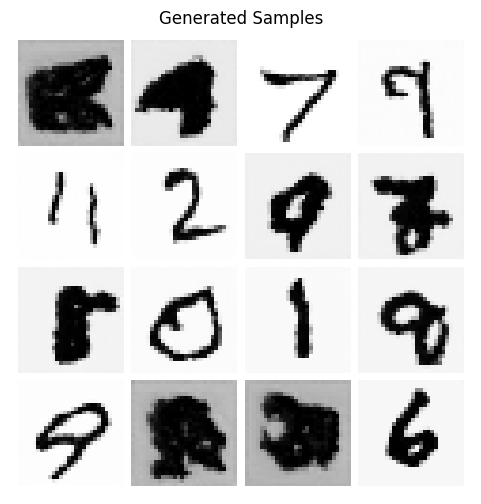

In [ ]:
for schedule in beta_schedules:
    print(f"Training with {schedule} schedule")

    scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }

    plot_noise(scheduler_kwargs)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)

    trainer.train(train_dataloader, epochs=10)

    plot_generated_samples(trainer.sample(num_samples=16), title=f"Generated Samples with {schedule} schedule")


### Hyperparameter tuning

In [ ]:
# Run hyperparameter tuning with Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
torch.save(
                study.best_params,
                "/content/drive/MyDrive/Diffusion/ddpm_best_parameters_20trials.pt"
            )
print("Best hyperparameters:", study.best_params)


[I 2025-06-08 16:55:23,141] A new study created in memory with name: no-name-1c3a0428-8560-4c95-a6dc-1d0d5f83dbd8
[I 2025-06-08 16:55:26,069] Trial 0 finished with value: 0.8846594637090509 and parameters: {'beta_schedule': 'scaled_linear', 'beta_start': 1.2208978106362772e-05, 'beta_end': 0.038103763525795545, 'lr': 9.699609824934948e-05}. Best is trial 0 with value: 0.8846594637090509.
[I 2025-06-08 16:55:28,995] Trial 1 finished with value: 0.5691005641763861 and parameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.0007758723177775468, 'beta_end': 0.04533181927799606, 'lr': 0.0002088727760958186}. Best is trial 1 with value: 0.5691005641763861.
[I 2025-06-08 16:55:31,826] Trial 2 finished with value: 0.9952008290724321 and parameters: {'beta_schedule': 'scaled_linear', 'beta_start': 0.0002681767385776806, 'beta_end': 0.16012811198850238, 'lr': 7.027922778964147e-05}. Best is trial 1 with value: 0.5691005641763861.
[I 2025-06-08 16:55:34,673] Trial 3 finished with value: 0.776209

Best hyperparameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.00014943600232321147, 'beta_end': 0.08302639649349275, 'lr': 0.00034203432394422926}


In [ ]:
file_path = "/content/drive/MyDrive/Diffusion/ddpm_best_parameters_20trials.pt"

best_params = torch.load(file_path)

print("Best parameters:", best_params)


Best parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 0.00015064770460850388, 'beta_end': 0.07062676916106778, 'lr': 0.0008923503813371513}


#### Generating images with set hyperparameter

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1/20, Avg Loss: 0.07629
Epoch 2/20, Avg Loss: 0.04868
Epoch 3/20, Avg Loss: 0.04542
Epoch 4/20, Avg Loss: 0.04326
Epoch 5/20, Avg Loss: 0.04259
Epoch 6/20, Avg Loss: 0.04148
Epoch 7/20, Avg Loss: 0.04073
Epoch 8/20, Avg Loss: 0.04052
Epoch 9/20, Avg Loss: 0.03994
Epoch 10/20, Avg Loss: 0.03967
Epoch 11/20, Avg Loss: 0.03937
Epoch 12/20, Avg Loss: 0.03915
Epoch 13/20, Avg Loss: 0.03890
Epoch 14/20, Avg Loss: 0.03863
Epoch 15/20, Avg Loss: 0.03845
Epoch 16/20, Avg Loss: 0.03837
Epoch 17/20, Avg Loss: 0.03834
Epoch 18/20, Avg Loss: 0.03841
Epoch 19/20, Avg Loss: 0.03841
Epoch 20/20, Avg Loss: 0.03824


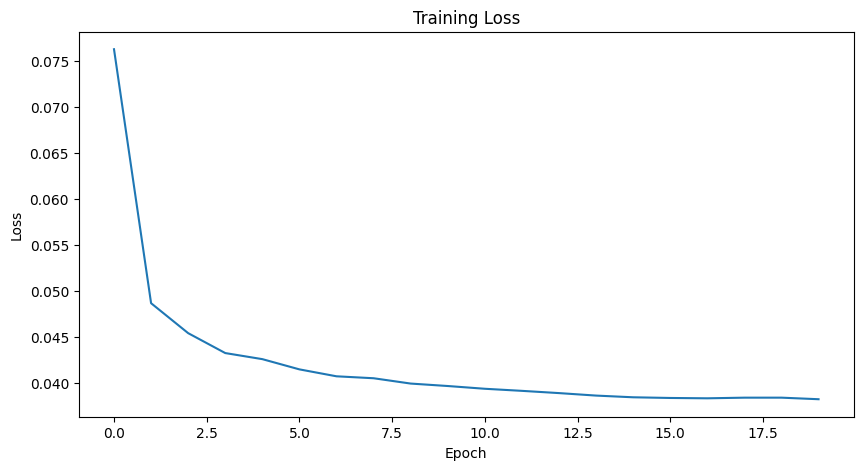

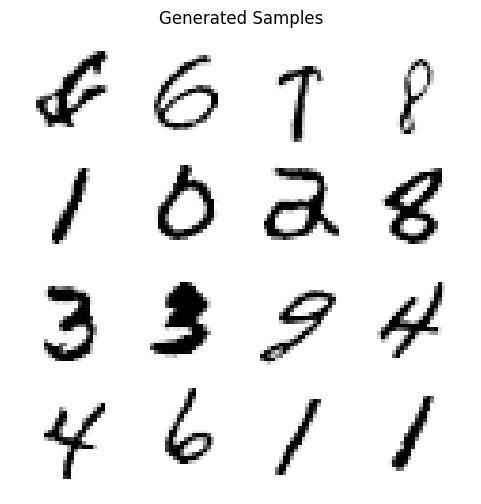

In [ ]:

trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])

trainer.train(train_dataloader, epochs=20)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


Best hyperparameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.00014943600232321147, 'beta_end': 0.08302639649349275, 'lr': 0.00034203432394422926}
Epoch 1/20, Avg Loss: 0.07720
Epoch 2/20, Avg Loss: 0.04933
Epoch 3/20, Avg Loss: 0.04555
Epoch 4/20, Avg Loss: 0.04394
Epoch 5/20, Avg Loss: 0.04275
Epoch 6/20, Avg Loss: 0.04180
Epoch 7/20, Avg Loss: 0.04095
Epoch 8/20, Avg Loss: 0.04035
Epoch 9/20, Avg Loss: 0.04010
Epoch 10/20, Avg Loss: 0.03946
Epoch 11/20, Avg Loss: 0.03953
Epoch 12/20, Avg Loss: 0.03914
Epoch 13/20, Avg Loss: 0.03901
Epoch 14/20, Avg Loss: 0.03881
Epoch 15/20, Avg Loss: 0.03876
Epoch 16/20, Avg Loss: 0.03851
Epoch 17/20, Avg Loss: 0.03844
Epoch 18/20, Avg Loss: 0.03838
Epoch 19/20, Avg Loss: 0.03815
Epoch 20/20, Avg Loss: 0.03768


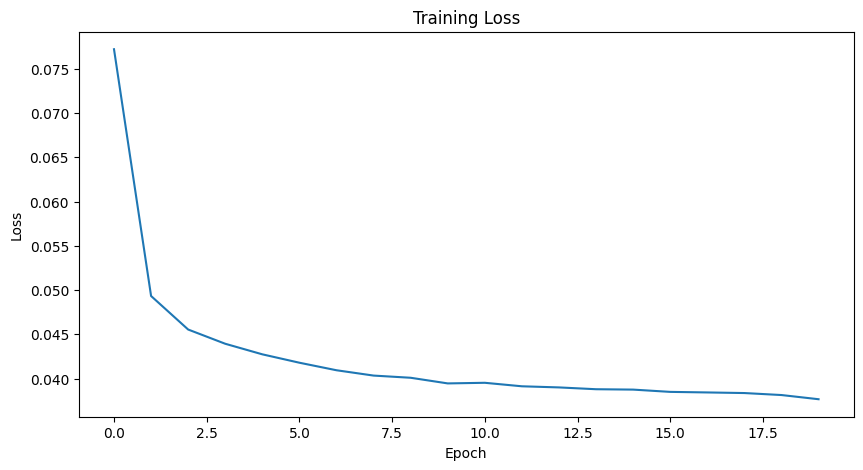

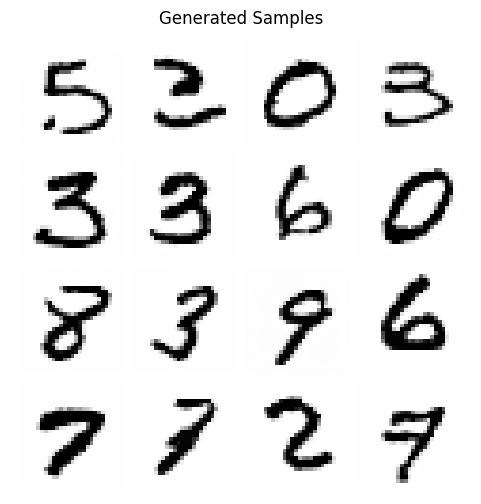

In [ ]:
trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])
print("Best hyperparameters:", study.best_params)

trainer.train(train_dataloader, epochs=20)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


#trying cats

In [ ]:


class CatDiffusionTrainer:
    """
    A class encapsulating the training and sampling procedures of a Denoising Diffusion Probabilistic Model (DDPM).

    This class implements:
    - Forward diffusion process using a noise scheduler (q(x_t | x_0))
    - Training of a UNet neural network to predict added noise at any timestep
    - Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None, lr=1e-4):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            scheduler_kwargs: Dictionary of keyword arguments to customize the DDPMScheduler.
                Accepts keys such as:
                    - beta_schedule (str): e.g., "linear", "scaled_linear", "squaredcos_cap_v2"
                    - beta_start (float): Initial beta value for linear schedules
                    - beta_end (float): Final beta value for linear schedules
                    - num_train_timesteps (int): Total number of diffusion steps
            lr: Learning rate for the optimizer
        """
        self.device = device
        self.model = UNet2DModel(
            sample_size=128,
            in_channels=3,
            out_channels=3,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {
                "beta_schedule": "squaredcos_cap_v2",
                "num_train_timesteps": 1000
            }

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for i, (batch, _) in enumerate(dataloader):
                if i>=50:
                  break
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

            torch.save(
                self.model.state_dict(),
                f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_{self.noise_scheduler.config.beta_schedule}_cat_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generate images by reversing the diffusion process starting from noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 3, 128, 128, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img


def objective(trial):
    """
    Optuna objective function for hyperparameter tuning of the DDPM.
    Tunes the beta_start, beta_end, and learning rate.
    """
    scheduler_params = {
        "beta_schedule": trial.suggest_categorical("beta_schedule", ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]),
        "beta_start": trial.suggest_float("beta_start", 1e-5, 1e-3, log=True),
        "beta_end": trial.suggest_float("beta_end", 0.01, 0.2),
        "num_train_timesteps": 1000
    }
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params, lr=lr)
    trainer.model.train()

    losses = []
    for batch, _ in train_dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, trainer.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_batch = trainer.noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = trainer.model(noisy_batch, timesteps).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        trainer.optimizer.zero_grad()
        loss.backward()
        trainer.optimizer.step()

        losses.append(loss.item())
        if len(losses) > 10:
            break

    return sum(losses) / len(losses)

def plot_noise(scheduler_kwargs=None):
    if scheduler_kwargs is None:
        scheduler_kwargs = {}

    # Initialize the noise scheduler
    noise_scheduler = DDPMScheduler(**scheduler_kwargs)
    schedule_name = scheduler_kwargs.get("beta_schedule", "Unknown Schedule")

    # Plot the square root of alphas_cumprod
    plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"$\sqrt{\bar{\alpha}_t}$")

    # Plot the square root of (1 - alphas_cumprod)
    plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{1 - \bar{\alpha}_t}$")

    # Add labels and legend
    plt.xlabel('Time step')
    plt.ylabel('Value')
    if schedule_name:
        plt.title(f'Noise Scheduler Parameters with {schedule_name}')
    else:
        plt.title('Noise Scheduler Parameters')
    plt.legend(fontsize="x-large")

    # Show the plot
    plt.show()

def plot_generated_samples(samples, num_samples=16, title="Generated Samples"):
    """
    Plot a grid of generated samples.

    Args:
        samples: A batch of generated images as a torch tensor.
        num_samples: Number of samples to plot.
        title: Title for the plot.
    """
    grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

    plt.figure(figsize=(6, 6))
    plt.title("Generated Samples")
    plt.imshow(grid[0], cmap='Greys')
    plt.axis('off')
    plt.show()




In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transforms: resize, convert to tensor, normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0)  # scale from [0,1] to [-1,1]
])

# Path to AFHQ-512  dataset
data_path = "/content/drive/MyDrive/Diffusion/Datasets/afhq-512"

# Load dataset
dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Create DataLoader
train_dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Loaded {len(dataset)} images.")

Using device: cuda
Loaded 5558 images.


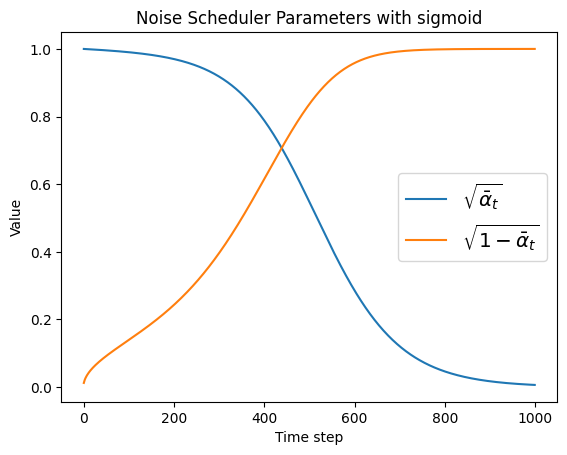

OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 52.12 MiB is free. Process 5609 has 14.69 GiB memory in use. Of the allocated memory 14.13 GiB is allocated by PyTorch, and 445.07 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

    # Define scheduler kwargs
    scheduler_kwargs = {
        "beta_schedule": "sigmoid",
        "num_train_timesteps": 1000
    }

    # Plot the noise schedule
    plot_noise(scheduler_kwargs)

    # Initialize the DiffusionTrainer
    trainer = CatDiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)

    # Train the model for 5 epochs
    trainer.train(train_dataloader, epochs=10)

    plot_generated_samples(trainer.sample(num_samples=16), title=f"Generated Samples with {schedule} schedule")